# Rough Volatility (rBergomi)

Bayer, Friz, Gatheral (2016), *Pricing under rough volatility*.

This week is the conceptual break from W5 to W8. Every model in the toolkit so far
had a state that factorises through the present, which is exactly what gave us a
characteristic function and let us price with COS and Carr-Madan. rBergomi is the
first model that structurally refuses: variance is driven by a Volterra process with
a singular power-law kernel, so the state is path-dependent, non-Markovian, has no
closed-form characteristic function, and cannot be priced by COS. We return to Monte
Carlo, back to the W1/W4 discipline (report SE, z-score sanity, certify by
convergence rate not single points).

The payoff for that pain is the skew term structure. Roughness produces an ATM skew
that goes like a power law $\psi(\tau)\sim\tau^{H-1/2}$, which explodes into the short
end and persists into the long end with one exponent. Markovian models (Heston, Bates)
decay skew exponentially and cannot do both, which is precisely the flattening you
observed directly in real SPX at 30 vs 75 DTE.

## 1. Motivation: two empirical pillars

Roughness is supported by two independent bodies of evidence.

**Options side (skew power law).** The empirical ATM skew
$\psi(\tau)=|\partial_k\sigma_{\text{BS}}(k,\tau)|_{k=0}$ behaves like $\tau^{-\alpha}$
with $\alpha\approx0.4$, blowing up at short maturities. A stochastic-vol model
reproduces this only if its variance driver is rough with $H=\tfrac12-\alpha\approx0.1$.

**Time-series side (rough realized variance).** Gatheral, Jaisson, Rosenbaum (2018),
*Volatility is rough*, estimate $H$ directly from realized-variance series via the
scaling

$$\mathbb{E}\left|\log\sigma_{t+\delta}-\log\sigma_t\right|^{q}\sim\delta^{qH},$$

and find $H\approx0.1$ across thousands of assets, far rougher than any semimartingale
($H=\tfrac12$).

**Where the arc lands.** Local vol gets dynamics wrong; Heston fixes the level via
stochastic vol but is Markovian, so it flattens the skew term structure too fast;
jumps add short-dated skew a diffusion cannot; Bates combines them; and rough vol
fixes the *persistent term-structure* problem with a single roughness exponent. This
notebook is the last classical model of Phase 1, and its ML capstone (deep calibration)
is the first ML piece.

## 2. Fractional and Volterra Gaussian processes

**Fractional Brownian motion.** $B^H$ is the centred Gaussian process with

$$\mathbb{E}[B^H_s B^H_t]=\tfrac12\left(s^{2H}+t^{2H}-|t-s|^{2H}\right),\qquad H\in(0,1).$$

At $H=\tfrac12$ this is $\min(s,t)$, standard BM. It is self-similar
($B^H_{at}\overset{d}{=}a^H B^H_t$) with stationary increments

$$\mathbb{E}[(B^H_t-B^H_s)^2]=|t-s|^{2H}.$$

The increment autocovariance scales like $H(2H-1)k^{2H-2}$; for $H<\tfrac12$ that
prefactor is negative, so increments are anti-persistent (every move tends to reverse,
which is what makes a path look jagged). Paths are almost surely Hölder-$\gamma$ for
every $\gamma<H$ and no higher, so $H$ is the critical regularity exponent. Small $H$
is rough.

**The Volterra (Riemann-Liouville) process rBergomi uses.** Not fBm itself, but

$$\widetilde W_t=\sqrt{2H}\int_0^t(t-s)^{H-1/2}\,dW_s,\qquad
\text{Var}(\widetilde W_t)=2H\int_0^t(t-s)^{2H-1}\,ds=t^{2H}.$$

The $\sqrt{2H}$ normalises to the roughness scaling $t^{2H}$. The kernel exponent
$H-\tfrac12\in(-\tfrac12,0)$ for $H<\tfrac12$, so the kernel is *singular at $s=t$*:
it blows up (does not vanish) as $s\to t$, integrably because $H>0$.

Typical size of a move over horizon $\tau$ is the standard deviation,

$$\sqrt{\text{Var}(\widetilde W_\tau)}=\sqrt{\tau^{2H}}=\tau^{H}.$$

For $H<\tfrac12$, $\tau^{H}\gg\tau^{1/2}$ as $\tau\to0$, so the driver moves *much more*
than a diffusion over short horizons. This excess short-horizon motion is the engine
of the short-dated skew.

At $H=\tfrac12$ everything collapses to the familiar case: kernel $\equiv1$,
$\sqrt{2H}=1$, $\widetilde W_t=W_t$, and $v_t$ becomes a Markovian lognormal
(classical flat-Bergomi).

## 3. Why non-Markovian, and why COS is dead

$v_t$ integrates the *entire* history of $W$ against the kernel $(t-s)^{H-1/2}$,
weighted most heavily on the *recent* past (near the singularity at $s=t$) and decaying
into the distant past. Markov is not about recent-vs-distant weighting; it is about
whether the whole past compresses into the current value. It does not here, and the
reason is that the kernel does not factorise.

Contrast the OU / Heston kernel $e^{-\kappa(t-s)}$, which splits as
$e^{-\kappa\,dt}e^{-\kappa(t-s)}$, the $dt$ factor being $s$-free so it pulls out of
the integral:

$$Y_{t+dt}=\int_0^{t+dt}e^{-\kappa(t+dt-s)}\,dW_s
=e^{-\kappa\,dt}\,Y_t+\int_t^{t+dt}e^{-\kappa(t+dt-s)}\,dW_s.$$

The entire past collapses into one carried number $Y_t$. This *pull-out* is what makes
an exponential-kernel process Markov. A power law admits no identity
$(a+b)^p=f(a)\,g(b)^p$; the $dt$ stays welded inside the base, entangled with every
$s$. Advancing time re-scores the whole history against a new profile rather than
scaling a carried state, so you must keep the full path.

Consequence: $(X_t,v_t)$ is not a sufficient state, so there is no finite-dimensional
generator, no PDE, and no closed-form characteristic function. The affine-Riccati
machinery of W5 to W8 is gone. **Pricing is Monte Carlo.**

## 4. The rBergomi model

Under the pricing measure, with $r=0$ (forward measure; reinstate discounting
downstream),

$$v_t=\xi_0(t)\,\exp\left(\eta\,\widetilde W_t-\tfrac12\eta^2 t^{2H}\right),$$

$$\frac{dS_t}{S_t}=\sqrt{v_t}\,dW^S_t,\qquad
W^S=\rho\,W+\sqrt{1-\rho^2}\,W^\perp.$$

**Martingale correction, forced not chosen.** We want $\mathbb{E}[v_t]=\xi_0(t)$ so
that $\xi_0$ is genuinely the forward variance curve (the market input from variance
swaps / VIX). Since $\eta\widetilde W_t\sim\mathcal N(0,\eta^2 t^{2H})$ and
$\mathbb{E}[e^X]=e^{m+\sigma^2/2}$ for Gaussian $X$,

$$\mathbb{E}\left[e^{\eta\widetilde W_t}\right]=e^{\frac12\eta^2 t^{2H}}.$$

Multiplying by the reciprocal $e^{-\frac12\eta^2 t^{2H}}$ pins the mean to exactly $1$.
The $t^{2H}$ is $\text{Var}(\widetilde W_t)$; it re-pins itself automatically if $H$
changes. This is the same Doléans-Dade move as before, in plain lognormal form.

**Parameters and what each controls.**

| Parameter | Role | Acts on |
|---|---|---|
| $H\in(0,\tfrac12)$ | roughness (Hölder exponent) | the *exponent* of the skew term structure ($\tau^{H-1/2}$), i.e. its log-log slope |
| $\eta>0$ | vol-of-vol | the *amplitude* of the skew and smile |
| $\rho<0$ | price/vol correlation | the *sign and presence* of skew (no $\rho$, no tilt) |
| $\xi_0(\cdot)$ | forward variance curve | the *level and term structure of variance* (market input) |

$H$ rotates the log-log skew line; $\eta$ shifts it vertically. Rotation and shift are
independent, which is why calibration is well-posed and why $H,\eta$ do not degenerate
into each other. A pinned $\eta$ with interior $H$ is therefore a data or $\xi_0$
problem, not a roughness problem.

## 5. Short-time skew asymptotics

Power-counting heuristic (exponent robust, constant model-specific). Skew is
correlation times "vol motion measured against the price's own diffusive yardstick,"
each over horizon $\tau$:

$$\psi(\tau)\sim\rho\,\eta\cdot\frac{\text{vol driver move over }\tau}
{\text{price diffusive scale over }\tau}
\sim\rho\,\eta\cdot\frac{\tau^{H}}{\tau^{1/2}}=\rho\,\eta\,\tau^{\,H-1/2}.$$

Regimes from the exponent $H-\tfrac12$:

- $H=\tfrac12$: $\tau^0=$ const, skew flattens to a finite short-end value (the classical failure).
- $H<\tfrac12$: exponent negative, skew explodes as $\tau\to0$ (matches market; $H\approx0.1$ gives $\approx\tau^{-0.4}$).

At the long end the power law decays *polynomially*, whereas a Markovian model's
exponential-kernel autocovariance $e^{-\kappa\tau}$ decays *exponentially* and dies too
fast. One roughness exponent fixes both ends; this is the 30-vs-75 DTE flattening.

Two honesty notes. The heuristic gets the exponent right but the rigorous short-time
result is a theorem (Fukasawa; Bayer, Friz, Gatheral). And $\tau^{H-1/2}$ is a
short-$\tau$ statement; across the full surface $\xi_0$ and $\eta$ also shape things, so
do not expect a perfect single slope across all maturities. The log-log skew fit
(Demo 4) recovers a slope *near* $H-\tfrac12$, which is enough to see the roughness.

**Identifiability corollary.** Roughness is a multi-maturity phenomenon by
construction: one maturity is one point on the log-log line, and you cannot fit a slope
to one point. This is exactly why the single-slice W8 benchmark could not test it, and
why the deferred multi-maturity benchmark becomes essential here.

## 6. Simulation strategy (ground-truth-first)

No characteristic function, so we simulate. Build the **exact (Cholesky)** simulator
first as ground truth, then optionally the **hybrid scheme** (Bennedsen, Lunde,
Pakkanen 2017, $O(N\log N)$) as the fast production version, and check they agree.

We need the joint Gaussian of the Volterra values $\widetilde W_{t_i}$ and the driving
BM $W_{t_i}$, because the price uses $W^S=\rho W+\sqrt{1-\rho^2}W^\perp$ and the skew
comes from the price sharing $W$ with $\widetilde W$. Closed-form covariances on the
grid, for $s\le t$:

$$\mathbb{E}[\widetilde W_s\widetilde W_t]
=2H\int_0^s (s-u)^{H-1/2}(t-u)^{H-1/2}\,du
\qquad(\text{diagonal}=t^{2H}),$$

$$\mathbb{E}[W_s W_t]=\min(s,t),$$

$$\mathbb{E}[\widetilde W_t\, W_s]
=\frac{\sqrt{2H}}{H+\tfrac12}\left(t^{H+1/2}-(t-\min(s,t))^{H+1/2}\right).$$

The autocovariance integral has a closed form via ${}_2F_1$, or evaluate it by
quadrature; either is fine, and we verify the simulator against it regardless.
Assemble the $2N\times2N$ joint covariance $\Sigma$ from these three blocks,
Cholesky-factor once, and map an $(n_{\text{paths}},2N)$ iid standard-normal draw
through the factor.

**Implementation caution.** The $\Delta W$ increments used to build the price's $W^S$
must be the *same* Brownian increments that built $\widetilde W$; that shared $W$ is
the leverage channel. If you draw an independent BM for the price you will get zero
skew regardless of $\rho$.

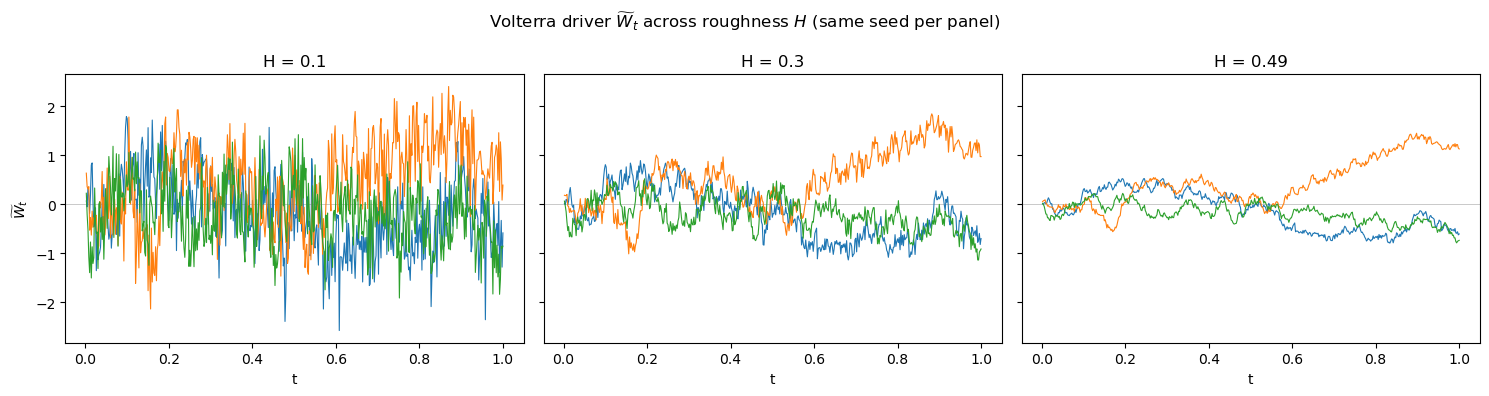

In [4]:
# Demo 1: rough paths across H (visual roughness + the same-shocks caveat)
import numpy as np
import matplotlib.pyplot as plt
from models.rbergomi import simulate_rbergomi, RBergomiParams

t_grid = np.linspace(1/500, 1.0, 500)          # fine grid: roughness lives at small scales
V0 = 0.04
xi0 = lambda t: np.full_like(np.asarray(t, dtype=float), V0)
H_values = (0.1, 0.3, 0.49)
n_show = 3                                       # few paths: 500-pt Cholesky is heavy

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, H in zip(axes, H_values):
    params = RBergomiParams(H=H, eta=1.5, rho=-0.9, xi0=xi0)
    rng = np.random.default_rng(0)   # SAME seed each H, see caveat below
    _, _, W_tilde = simulate_rbergomi(t_grid, params, n_show, rng)
    for k in range(n_show):
        ax.plot(t_grid, W_tilde[k], lw=0.8)
    ax.set_title(f"H = {H}")
    ax.set_xlabel("t")
    ax.axhline(0.0, color="0.7", lw=0.5, zorder=0)

axes[0].set_ylabel(r"$\widetilde{W}_t$")
fig.suptitle(r"Volterra driver $\widetilde{W}_t$ across roughness $H$ (same seed per panel)")
fig.tight_layout()
plt.show()

That is the textbook picture. H=0.1 never settles, it is all high-frequency jitter with no trend, which is the anti-persistence made visible: every move tends to reverse, so the path fills space rather than wandering. H=0.49 looks like ordinary Brownian motion, smooth wandering with visible trends, and H=0.3 sits exactly between. That is the roughness spectrum, and it confirms the driver by eye before you trust any of the quantitative demos.

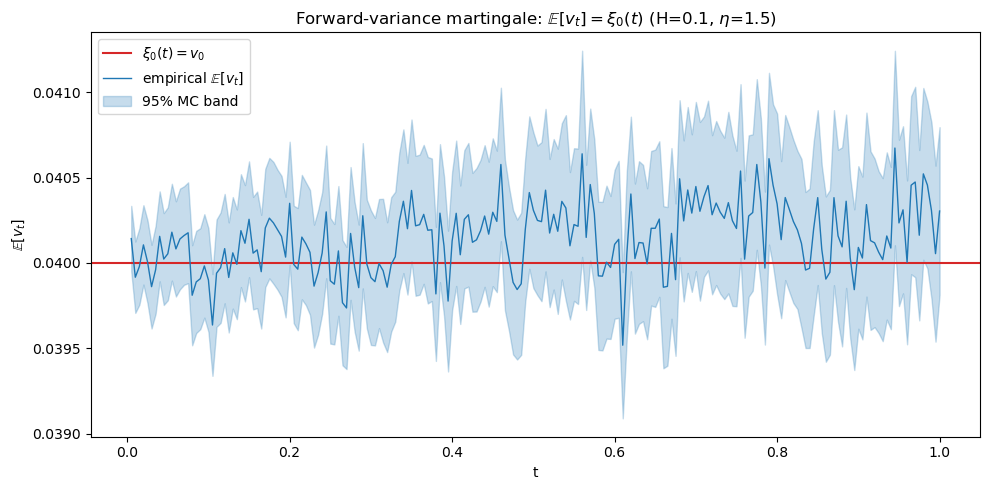

max |z| across grid: 2.51  (expect ~O(1-3), flat band on 0.04)


In [5]:
# Demo 2: E[v_t] = xi0(t) martingale check (visual companion to test_forward_variance_is_xi0)
t_grid = np.linspace(1/200, 1.0, 200)
V0 = 0.04
xi0 = lambda t: np.full_like(np.asarray(t, dtype=float), V0)
params = RBergomiParams(H=0.1, eta=1.5, rho=-0.9, xi0=xi0)

n_paths = 200_000
rng = np.random.default_rng(0)
_, v, _ = simulate_rbergomi(t_grid, params, n_paths, rng)

emp_mean = v.mean(axis=0)
se = v.std(axis=0, ddof=1) / np.sqrt(n_paths)   # per-t standard error of the mean

fig, ax = plt.subplots(figsize=(10, 5))
ax.axhline(V0, color="C3", lw=1.5, label=r"$\xi_0(t) = v_0$")
ax.plot(t_grid, emp_mean, color="C0", lw=1.0, label=r"empirical $\mathbb{E}[v_t]$")
ax.fill_between(t_grid, emp_mean - 1.96 * se, emp_mean + 1.96 * se,
                color="C0", alpha=0.25, label="95% MC band")
ax.set_xlabel("t")
ax.set_ylabel(r"$\mathbb{E}[v_t]$")
ax.set_title(r"Forward-variance martingale: $\mathbb{E}[v_t] = \xi_0(t)$ (H=0.1, $\eta$=1.5)")
ax.legend()
fig.tight_layout()
plt.show()

# quick numeric readout: worst-case z across the grid
z = np.abs(emp_mean - V0) / se
print(f"max |z| across grid: {z.max():.2f}  (expect ~O(1-3), flat band on 0.04)")

The empirical mean oscillates tightly around 0.04 with no systematic drift, the band widens toward larger t exactly as predicted (v disperses as t^{2H} grows, so the SE of the mean grows), and max |z| = 2.51 is textbook for 200 grid points, you expect the worst of 200 roughly-standard-normal z-scores to land around 2.5 to 3 by pure extremes. Nothing to flag. The martingale correction is confirmed visually, and the fact that a broken correction would have lifted the whole curve toward 0.12 by t=1 means this plot has real diagnostic teeth, not just a flat-line rubber stamp.

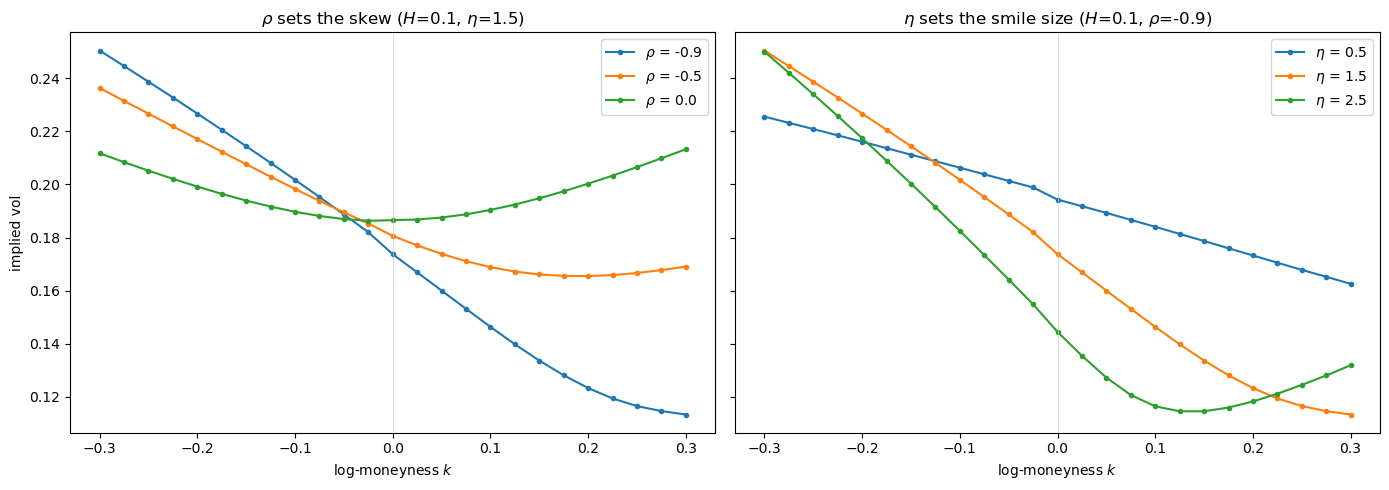

In [6]:
from pricing.monte_carlo import european_price_from_samples
from calibration.implied_vol import bsm_implied_vol

# Demo 3: Smiles
t_grid = np.linspace(1/200, 1.0, 200)
T = t_grid[-1]
V0 = 0.04
xi0 = lambda t: np.full_like(np.asarray(t, dtype=float), V0)

k = np.linspace(-0.30, 0.30, 25)          # log-moneyness; forward = 1 so ATM is k=0
strikes = np.exp(k)
n_paths = 300_000

def rbergomi_smile(params, seed=0):
    rng = np.random.default_rng(seed)
    S, _, _ = simulate_rbergomi(t_grid, params, n_paths, rng)
    S_T = S[:, -1]
    iv = np.empty_like(strikes)
    for i, K in enumerate(strikes):
        otype = "call" if K >= 1.0 else "put"      # price OTM side, more signal, tighter IV
        price, _ = european_price_from_samples(S_T, K, r=0.0, T=T, option_type=otype)
        iv[i] = bsm_implied_vol(price, S=1.0, K=K, T=T, r=0.0, option_type=otype)
    return iv

# --- Sweep 1: rho controls the skew (tilt) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for rho in (-0.9, -0.5, 0.0):
    iv = rbergomi_smile(RBergomiParams(H=0.1, eta=1.5, rho=rho, xi0=xi0))
    m = ~np.isnan(iv)
    ax1.plot(k[m], iv[m], marker=".", label=f"$\\rho$ = {rho}")
ax1.axvline(0.0, color="0.8", lw=0.5)
ax1.set_xlabel("log-moneyness $k$"); ax1.set_ylabel("implied vol")
ax1.set_title(r"$\rho$ sets the skew ($H$=0.1, $\eta$=1.5)"); ax1.legend()

# --- Sweep 2: eta controls the smile size (convexity + skew magnitude) ---
for eta in (0.5, 1.5, 2.5):
    iv = rbergomi_smile(RBergomiParams(H=0.1, eta=eta, rho=-0.9, xi0=xi0))
    m = ~np.isnan(iv)
    ax2.plot(k[m], iv[m], marker=".", label=f"$\\eta$ = {eta}")
ax2.axvline(0.0, color="0.8", lw=0.5)
ax2.set_xlabel("log-moneyness $k$")
ax2.set_title(r"$\eta$ sets the smile size ($H$=0.1, $\rho$=-0.9)"); ax2.legend()

fig.tight_layout()
plt.show()

Left panel, rho sweep. rho = -0.9 gives the steep downward equity skew, puts bid over calls. rho = 0 is the near-symmetric smile, both wings turning up around a flat minimum near ATM, which is the pure-convexity case with no leverage tilt. rho = -0.5 sits between, tilted but still curving up on the call side. The three curves crossing in a tight pencil just left of ATM is the signature you want: rho rotates the smile about a near-fixed point, it does not move the level. That is the "rho is a rotation" picture made visual, and it is the counterpart to the identifiability argument from Day 43, rho and eta act on different axes.

Right panel, eta sweep. This is the one that confirms the amplitude story cleanly. eta = 0.5 is nearly flat, a gentle tilt with little curvature. eta = 2.5 is deep and strongly curved. Bigger eta lifts convexity and steepens the skew together, because eta multiplies the whole deviation from flat. Note eta = 0.5 barely smiles at all, which is the right limit, small vol-of-vol approaches a near-Black-Scholes flat surface.

One thing to notice and not misread: at eta = 2.5 the minimum of the smile has shifted well to the right of ATM, sitting around k = 0.1. That is not a bug. Strong vol-of-vol plus strong negative correlation pushes the risk-neutral density's mode and skews the whole IV curve so the trough moves off ATM. It is a known rBergomi feature at aggressive parameters, worth a one-line note in the narration so future-you does not flag it as an error later.

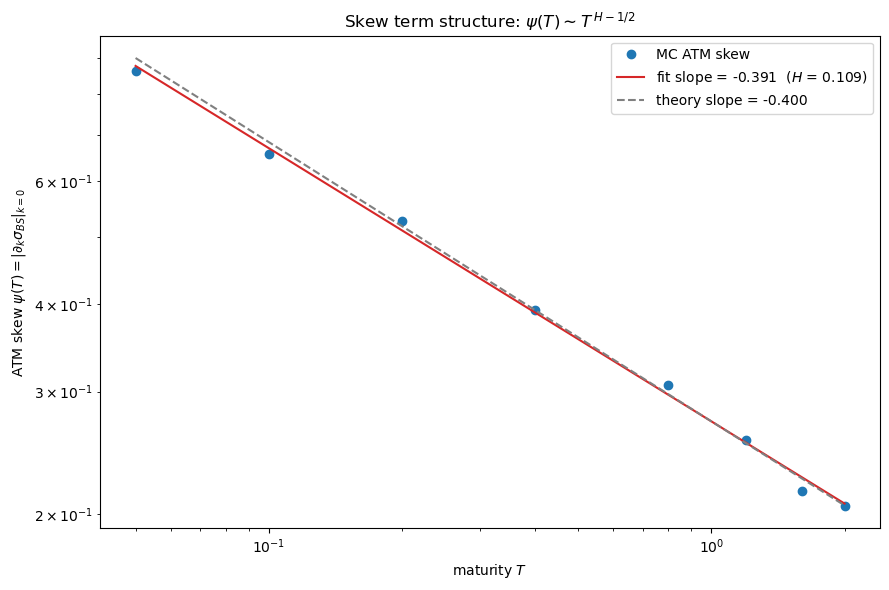

true H       : 0.1
fit slope    : -0.391   (theory H - 0.5 = -0.400)
recovered H  : 0.109


In [7]:
H_true = 0.1
V0 = 0.04
xi0 = lambda t: np.full_like(np.asarray(t, dtype=float), V0)
params = RBergomiParams(H=H_true, eta=1.5, rho=-0.9, xi0=xi0)

maturities = np.array([0.05, 0.1, 0.2, 0.4, 0.8, 1.2, 1.6, 2.0])   # short end weighted
k = np.linspace(-0.06, 0.06, 9)          # TIGHT window: local slope at k=0, not a wide average
strikes = np.exp(k)
n_paths = 400_000
n_steps_per_year = 200

def atm_skew(T, seed=0):
    """|d sigma_BS / dk| at k=0 for one maturity, via a local quadratic fit of IV(k)."""
    n_steps = max(20, int(round(n_steps_per_year * T)))   # keep grid fine: v_left bias ~ 1/N
    t_grid = np.linspace(T / n_steps, T, n_steps)
    rng = np.random.default_rng(seed)
    S, _, _ = simulate_rbergomi(t_grid, params, n_paths, rng)
    S_T = S[:, -1]

    iv = np.empty_like(strikes)
    for i, K in enumerate(strikes):
        otype = "call" if K >= 1.0 else "put"
        price, _ = european_price_from_samples(S_T, K, r=0.0, T=T, option_type=otype)
        iv[i] = bsm_implied_vol(price, S=1.0, K=K, T=T, r=0.0, option_type=otype)

    m = ~np.isnan(iv)
    # quadratic IV(k) = a k^2 + b k + c; skew = |b| = |dIV/dk| at k=0
    coeffs = np.polyfit(k[m], iv[m], deg=2)
    return abs(coeffs[1])

psi = np.array([atm_skew(T) for T in maturities])

# log-log fit: log psi = slope * log T + const, slope ~ H - 0.5
slope, intercept = np.polyfit(np.log(maturities), np.log(psi), 1)
H_recovered = slope + 0.5

fig, ax = plt.subplots(figsize=(9, 6))
ax.loglog(maturities, psi, "o", color="C0", label="MC ATM skew")
ax.loglog(maturities, np.exp(intercept) * maturities**slope, "-", color="C3",
          label=f"fit slope = {slope:.3f}  ($H$ = {H_recovered:.3f})")
ax.loglog(maturities, np.exp(intercept) * maturities**(H_true - 0.5), "--", color="0.5",
          label=f"theory slope = {H_true - 0.5:.3f}")
ax.set_xlabel("maturity $T$")
ax.set_ylabel(r"ATM skew $\psi(T) = |\partial_k \sigma_{BS}|_{k=0}$")
ax.set_title(r"Skew term structure: $\psi(T) \sim T^{\,H-1/2}$")
ax.legend()
fig.tight_layout()
plt.show()

print(f"true H       : {H_true}")
print(f"fit slope    : {slope:.3f}   (theory H - 0.5 = {H_true - 0.5:.3f})")
print(f"recovered H  : {H_recovered:.3f}")

### What this graph shows

Every point is one option maturity. For each maturity we priced a strip of options
across strikes, converted them to Black-Scholes implied volatilities, and measured
the **ATM skew**: how steeply the implied-vol curve tilts as you move from puts to
calls, right at the money. Puts trading richer than calls (the equity norm) shows up
as a downward tilt, and the skew is the steepness of that tilt. So the y-axis is "how
lopsided is the smile at this maturity," and the x-axis is the maturity itself.

The one empirical fact this whole model exists to explain: **short-dated options are
much more skewed than long-dated ones**, and the skew dies off as a *power law* in
maturity, $\psi(T) \sim T^{\,H-1/2}$. On a log-log plot a power law is a straight line
whose slope is the exponent, which is why we plot it this way. The eight points fall on
a straight line across almost two decades of maturity, so the power law holds, and the
slope we fit is $-0.391$.

Here is the payoff. That exponent is $H - \tfrac12$, where $H$ is the *roughness* of the
volatility process, so reading the slope backwards gives $H \approx 0.109$. We built the
simulator with $H = 0.1$, and nothing in the pricing or the skew-extraction was ever
told that value. We recovered it purely from the shape of simulated option prices. The
close match (0.109 vs 0.100) is the model working end to end: roughness put in at the
bottom comes back out, measured, at the top.

Why this matters beyond a consistency check. Ordinary stochastic-volatility models
(Heston and the like) cannot make this line. Their skew dies off *exponentially* with
maturity, far too fast, so they can fit the skew at one maturity but not across many at
once. Real markets show exactly the straight-line power-law decay above, which is why
rough volatility exists: a single roughness parameter $H \approx 0.1$ reproduces the
entire skew term structure that smooth models get wrong. The slight upward drift of the
shortest point and downward drift of the longest are expected, the power law is a
short-maturity result, so the far ends bend gently away as other effects enter.

## 7. Phase 1 ML capstone (stub, plan only)

**Deep calibration.** Train a neural network to approximate the map
$(H,\eta,\rho,\xi_0)\mapsto$ implied-vol surface, using the certified MC pricer above
as ground truth. This turns calibration from slow-MC-per-evaluation into a millisecond
forward pass, which is the industry use case that made rough vol practical.

Discipline (same as the whole project): the pricer is the ground truth, so **validate
the NN against the pricer, not the market**. Guiding principle: ML as a fast
approximator on a certified classical baseline, never a black-box predictor of a
low-signal quantity. Plan: fix a $\xi_0$ parameterisation, sample $(H,\eta,\rho)$ over
sensible ranges, generate surfaces with the MC pricer, train, then hold out and check
surface RMSE against fresh MC. Detailed design when we get here.